# 07- Full Evaluation and Comparison

### 1: Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/capstone'
print(f"Working from: {BASE}")

Mounted at /content/drive
Working from: /content/drive/MyDrive/capstone


### 2: Seeds and config

In [ ]:
#Setting fixed seeds to ensure reprodcible results
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

LABEL_NAMES = ['letter', 'form', 'email', 'handwritten', 'advertisement',
               'scientific report', 'scientific publication', 'specification',
               'file folder', 'news article', 'budget', 'invoice',
               'presentation', 'questionnaire', 'resume', 'memo']

print(f"Seed: {SEED} | Device: {DEVICE}")

Seed: 42 | Device: cuda


### 3: Install required packages

In [ ]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn tqdm --quiet
print("All packages are installed.")

All packages are installed.


### 4: Import libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
import os
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             confusion_matrix)
from collections import Counter

print("All imports are fine.")

All imports OK.


### 5: Load all saved results

In [ ]:
#Loading baseline results
with open(f"{BASE}/outputs/results/baseline_results.json") as f:
    baseline = json.load(f)

#Loading zero-shot VLM results
with open(f"{BASE}/outputs/results/vlm_results.json") as f:
    zeroshot = json.load(f)

#Loading fine-tuned DistilBERT results
with open(f"{BASE}/outputs/results/finetuned_results.json") as f:
    finetuned = json.load(f)

#Loading key field extraction results
with open(f"{BASE}/outputs/results/key_field_results.json") as f:
    key_field = json.load(f)

#Loading error analysis
with open(f"{BASE}/outputs/results/finetuned_error_analysis.json") as f:
    error_analysis = json.load(f)

print("All results are loaded successfully.")
print(f"\nBaseline accuracy  : {baseline['accuracy']}")
print(f"Zero-shot accuracy : {zeroshot['accuracy']}")
print(f"Fine-tuned accuracy: {finetuned['accuracy']}")

All results loaded successfully.

Baseline accuracy  : 0.566
Zero-shot accuracy : 0.07
Fine-tuned accuracy: 0.608


### 6: Full comparison table

In [ ]:
comparison = pd.DataFrame({
    "Method": [
        "OCR + TF-IDF + SVM (baseline)",
        "ViT zero-shot (M2)",
        "DistilBERT fine-tuned (M3)"
    ],
    "Accuracy": [
        baseline['accuracy'],
        zeroshot['accuracy'],
        finetuned['accuracy']
    ],
    "Macro F1": [
        baseline['macro_f1'],
        zeroshot['macro_f1'],
        finetuned['macro_f1']
    ],
    "Approach": [
        "OCR + classical ML",
        "Vision model zero-shot",
        "Transformer fine-tuned"
    ],
    "Requires OCR": ["Yes", "No", "Yes"],
    "Fine-tuned"  : ["No", "No", "Yes"]
})

print("=" * 75)
print("COMPLETE COMPARISON — ALL METHODS")
print("=" * 75)
print(comparison.to_string(index=False))
print("=" * 75)

comparison.to_csv(f"{BASE}/outputs/results/full_comparison.csv", index=False)
print("\nSaved to outputs/results/full_comparison.csv")

COMPLETE COMPARISON — ALL METHODS
                       Method  Accuracy  Macro F1               Approach Requires OCR Fine-tuned
OCR + TF-IDF + SVM (baseline)     0.566    0.5643     OCR + classical ML          Yes         No
           ViT zero-shot (M2)     0.070    0.0436 Vision model zero-shot           No         No
   DistilBERT fine-tuned (M3)     0.608    0.6026 Transformer fine-tuned          Yes        Yes

Saved to outputs/results/full_comparison.csv


### 7: Accuracy and F1 comparison bar chart

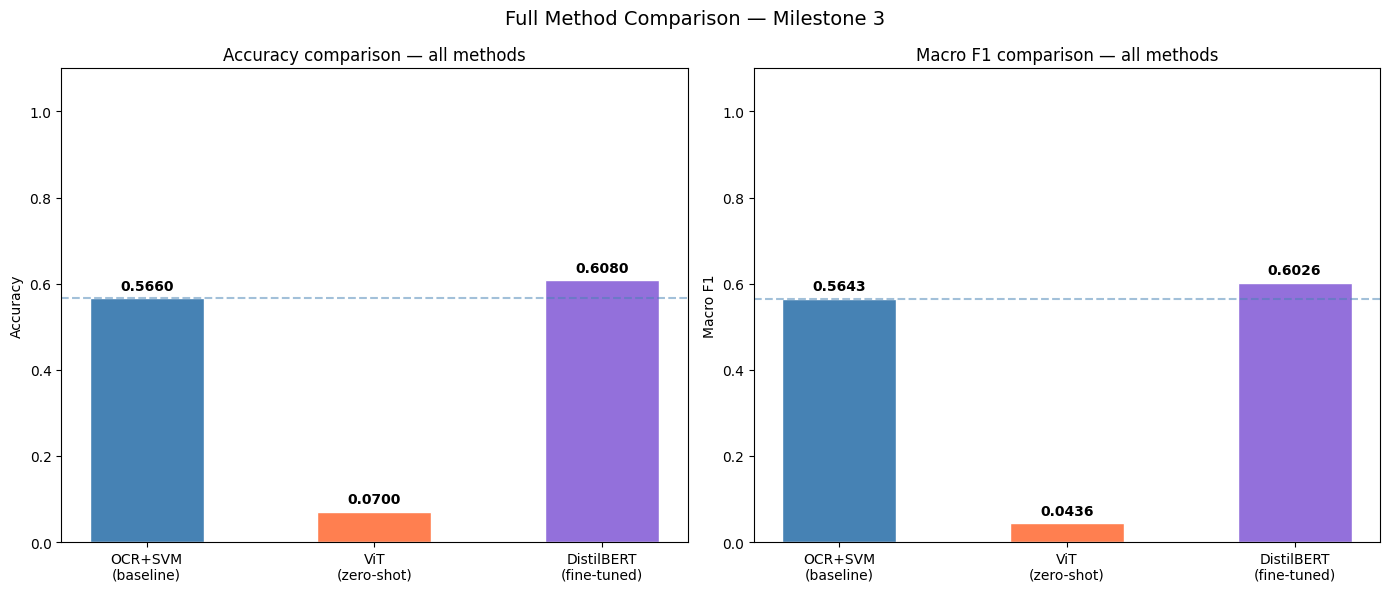

Full comparison chart saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods = ["OCR+SVM\n(baseline)",
           "ViT\n(zero-shot)",
           "DistilBERT\n(fine-tuned)"]
acc_vals = [baseline['accuracy'],
            zeroshot['accuracy'],
            finetuned['accuracy']]
f1_vals  = [baseline['macro_f1'],
            zeroshot['macro_f1'],
            finetuned['macro_f1']]
colors   = ['steelblue', 'coral', 'mediumpurple']

#Accuracy
bars = axes[0].bar(methods, acc_vals, color=colors,
                   edgecolor='white', width=0.5)
axes[0].set_title("Accuracy comparison — all methods", fontsize=12)
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=baseline['accuracy'], color='steelblue',
                linestyle='--', alpha=0.5, label='Baseline')
for bar, val in zip(bars, acc_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{val:.4f}", ha='center',
                 fontsize=10, fontweight='bold')

#Macro F1
bars = axes[1].bar(methods, f1_vals, color=colors,
                   edgecolor='white', width=0.5)
axes[1].set_title("Macro F1 comparison — all methods", fontsize=12)
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1.1)
axes[1].axhline(y=baseline['macro_f1'], color='steelblue',
                linestyle='--', alpha=0.5, label='Baseline')
for bar, val in zip(bars, f1_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{val:.4f}", ha='center',
                 fontsize=10, fontweight='bold')

plt.suptitle("Full Method Comparison", fontsize=14)
plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/full_comparison_chart.png", dpi=150)
plt.show()
print("Full comparison chart is saved.")

### 8: Load classification reports for detailed analysis

In [ ]:
#Loading baseline classification report
with open(f"{BASE}/outputs/results/baseline_classification_report.txt") as f:
    baseline_report = f.read()

print("BASELINE — OCR + TF-IDF + SVM")
print("=" * 60)
print(baseline_report)

BASELINE — OCR + TF-IDF + SVM
                        precision    recall  f1-score   support

                letter       0.50      0.62      0.55        21
                  form       0.53      0.56      0.55        32
                 email       0.81      0.74      0.77        34
           handwritten       0.32      0.32      0.32        31
         advertisement       0.56      0.56      0.56        34
     scientific report       0.48      0.29      0.36        35
scientific publication       0.70      0.65      0.68        40
         specification       0.50      0.72      0.59        18
           file folder       0.43      0.62      0.51        32
          news article       0.44      0.55      0.49        31
                budget       0.52      0.48      0.50        33
               invoice       0.43      0.41      0.42        29
          presentation       0.61      0.46      0.52        37
         questionnaire       0.86      0.58      0.69        43
         

### 9: Per class F1 comparison

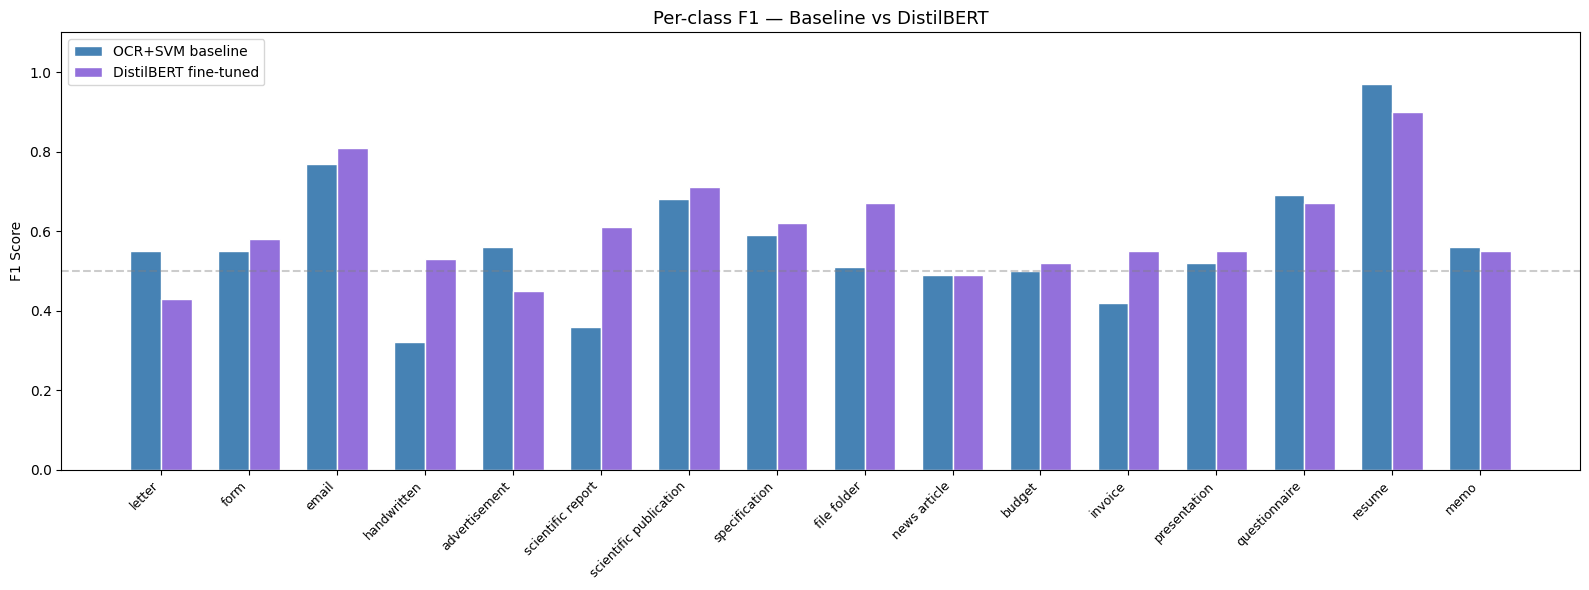

Per-class F1 comparison saved.


In [ ]:
# F1 values taken from notebook 03 and notebook 05 outputs

baseline_f1_per_class = {
    'letter'                : 0.55,
    'form'                  : 0.55,
    'email'                 : 0.77,
    'handwritten'           : 0.32,
    'advertisement'         : 0.56,
    'scientific report'     : 0.36,
    'scientific publication': 0.68,
    'specification'         : 0.59,
    'file folder'           : 0.51,
    'news article'          : 0.49,
    'budget'                : 0.50,
    'invoice'               : 0.42,
    'presentation'          : 0.52,
    'questionnaire'         : 0.69,
    'resume'                : 0.97,
    'memo'                  : 0.56
}

finetuned_f1_per_class = {
    'letter'                : 0.43,
    'form'                  : 0.58,
    'email'                 : 0.81,
    'handwritten'           : 0.53,
    'advertisement'         : 0.45,
    'scientific report'     : 0.61,
    'scientific publication': 0.71,
    'specification'         : 0.62,
    'file folder'           : 0.67,
    'news article'          : 0.49,
    'budget'                : 0.52,
    'invoice'               : 0.55,
    'presentation'          : 0.55,
    'questionnaire'         : 0.67,
    'resume'                : 0.90,
    'memo'                  : 0.55
}

#Plotting side by side
x      = np.arange(len(LABEL_NAMES))
width  = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width/2,
               [baseline_f1_per_class[l] for l in LABEL_NAMES],
               width, label='OCR+SVM baseline',
               color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2,
               [finetuned_f1_per_class[l] for l in LABEL_NAMES],
               width, label='DistilBERT fine-tuned',
               color='mediumpurple', edgecolor='white')

ax.set_title("Per-class F1 — Baseline vs DistilBERT", fontsize=13)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(LABEL_NAMES, rotation=45, ha='right', fontsize=9)
ax.legend()
#Using dashed line at 0.5 as reference for average performance
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/per_class_f1_comparison.png", dpi=150)
plt.show()
print("Per-class F1 comparison is saved.")

### 10: Error analysis comparison

In [ ]:
print("ERROR ANALYSIS — Fine-tuned DistilBERT")
print("=" * 60)
print(f"Total misclassified : {error_analysis['total_errors']} / {error_analysis['total_samples']}")
print(f"Accuracy            : {1 - error_analysis['total_errors']/error_analysis['total_samples']:.4f}")
print()
print("Top misclassification pairs (true → predicted):")
for item in error_analysis['top_confusions']:
    print(f"  {item['true']:25s} → {item['predicted']:25s} : {item['count']}")

ERROR ANALYSIS — Fine-tuned DistilBERT
Total misclassified : 196 / 500
Accuracy            : 0.6080

Top misclassification pairs (true → predicted):
  letter                    → memo                      : 6
  handwritten               → advertisement             : 6
  advertisement             → file folder               : 6
  budget                    → invoice                   : 5
  advertisement             → presentation              : 5
  scientific publication    → news article              : 5
  scientific publication    → scientific report         : 4
  form                      → advertisement             : 4
  questionnaire             → handwritten               : 4
  handwritten               → form                      : 4


### 11: Improvement analysis

Per-class improvement (DistilBERT vs Baseline):
  scientific report        : ↑ +0.250  █████
  handwritten              : ↑ +0.210  ████
  file folder              : ↑ +0.160  ███
  invoice                  : ↑ +0.130  ██
  email                    : ↑ +0.040  
  form                     : ↑ +0.030  
  scientific publication   : ↑ +0.030  
  specification            : ↑ +0.030  
  presentation             : ↑ +0.030  
  budget                   : ↑ +0.020  
  news article             : ↓ +0.000  
  memo                     : ↓ -0.010  
  questionnaire            : ↓ -0.020  
  resume                   : ↓ -0.070  █
  advertisement            : ↓ -0.110  ██
  letter                   : ↓ -0.120  ██


/tmp/ipykernel_1836/1829113347.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_sorted, rotation=45, ha='right', fontsize=9)


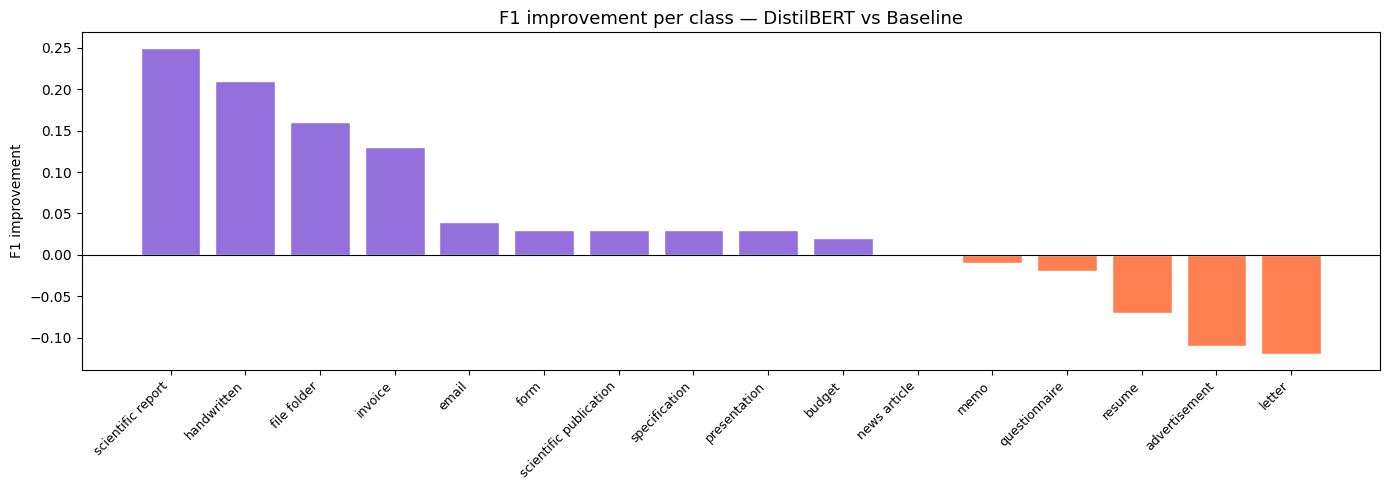

Improvement analysis saved.


In [ ]:
#Calculating F1 improvement for each class, if positive-> DistilBERT perfomed better than baseline on that class
improvements = {}
for label in LABEL_NAMES:
    base_f1 = baseline_f1_per_class[label]
    fine_f1 = finetuned_f1_per_class[label]
    improvements[label] = round(fine_f1 - base_f1, 3)

#Sorting by improvement
sorted_improvements = sorted(improvements.items(),
                              key=lambda x: x[1], reverse=True)

print("Per-class improvement (DistilBERT vs Baseline):")
print("=" * 50)
for label, imp in sorted_improvements:
    arrow = "↑" if imp > 0 else "↓"
    bar   = "█" * int(abs(imp) * 20)
    print(f"  {label:25s}: {arrow} {imp:+.3f}  {bar}")

#Plot
labels_sorted = [x[0] for x in sorted_improvements]
imps_sorted   = [x[1] for x in sorted_improvements]

#Purple = improvement, coral = regression vs baseline
colors_imp    = ['mediumpurple' if x >= 0 else 'coral' for x in imps_sorted]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(labels_sorted, imps_sorted,
              color=colors_imp, edgecolor='white')
ax.set_title("F1 improvement per class — DistilBERT vs Baseline",
             fontsize=13)
ax.set_ylabel("F1 improvement")
ax.set_xticklabels(labels_sorted, rotation=45, ha='right', fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(f"{BASE}/outputs/figures/improvement_analysis.png", dpi=150)
plt.show()
print("Improvement analysis is saved.")

### 12: Key field extraction summary

In [ ]:
print("KEY FIELD EXTRACTION RESULTS")
print("=" * 60)
print("\nFUNSD — Form Understanding:")
print(f"  Rule-based F1      : {key_field['funsd']['rule_based_f1']}")
print(f"  DistilBERT F1      : {key_field['funsd']['transformer_f1']}")
print(f"  Improvement        : +{key_field['funsd']['improvement']}")

print("\nSROIE — Invoice Field Extraction:")
print(f"  Rule-based avg acc : {np.mean(list(key_field['sroie']['rule_based_results'].values())):.4f}")
print(f"  DistilBERT acc     : {key_field['sroie']['transformer_acc']}")

KEY FIELD EXTRACTION RESULTS

FUNSD — Form Understanding:
  Rule-based F1      : 0.2412
  DistilBERT F1      : 0.2239
  Improvement        : +-0.0173

SROIE — Invoice Field Extraction:
  Rule-based avg acc : 0.6200
  DistilBERT acc     : 1.0


### 13: Reproducibility checklist

In [ ]:
checklist = {
    "code_and_environment": {
        "dependencies_listed"    : "Yes — requirements.txt in GitHub repo",
        "hardware_specified"     : "Google Colab T4 GPU",
        "random_seeds_set"       : f"Yes — SEED={SEED} in all notebooks"
    },
    "data": {
        "data_availability"      : "Public — RVL-CDIP, FUNSD, SROIE on HuggingFace/GitHub",
        "splits_defined"         : "Train: 4000 (80%) | Val: 500 (10%) | Test: 500 (10%)",
        "preprocessing_described": "Yes — notebook 02_preprocessing.ipynb"
    },
    "model_and_training": {
        "hyperparameters": {
            "learning_rate"      : finetuned['learning_rate'],
            "batch_size"         : finetuned['batch_size'],
            "epochs"             : finetuned['epochs'],
            "optimizer"          : finetuned['optimizer'],
            "scheduler"          : finetuned['scheduler']
        },
        "architecture"           : finetuned['model'],
        "best_model_saved"       : "Yes — best_distilbert_model.pt on Drive"
    }
}

with open(f"{BASE}/outputs/results/reproducibility_checklist.json", "w") as f:
    json.dump(checklist, f, indent=2)

print("REPRODUCIBILITY CHECKLIST")
print("=" * 60)
print(json.dumps(checklist, indent=2))

REPRODUCIBILITY CHECKLIST
{
  "code_and_environment": {
    "dependencies_listed": "Yes \u2014 requirements.txt in GitHub repo",
    "hardware_specified": "Google Colab T4 GPU",
    "random_seeds_set": "Yes \u2014 SEED=42 in all notebooks"
  },
  "data": {
    "data_availability": "Public \u2014 RVL-CDIP, FUNSD, SROIE on HuggingFace/GitHub",
    "splits_defined": "Train: 4000 (80%) | Val: 500 (10%) | Test: 500 (10%)",
    "preprocessing_described": "Yes \u2014 notebook 02_preprocessing.ipynb"
  },
  "model_and_training": {
    "hyperparameters": {
      "learning_rate": 2e-05,
      "batch_size": 32,
      "epochs": 3,
      "optimizer": "AdamW",
      "scheduler": "CosineAnnealingLR"
    },
    "architecture": "distilbert-base-uncased",
    "best_model_saved": "Yes \u2014 best_distilbert_model.pt on Drive"
  }
}


### 14: Final summary statistics

In [ ]:
#Final consolidated summary
summary = {
    "document_classification": {
        "baseline"  : {
            "method"  : "OCR + TF-IDF + LinearSVC",
            "accuracy": baseline['accuracy'],
            "macro_f1": baseline['macro_f1']
        },
        "zero_shot" : {
            "method"  : "ViT zero-shot",
            "accuracy": zeroshot['accuracy'],
            "macro_f1": zeroshot['macro_f1']
        },
        "finetuned" : {
            "method"  : "DistilBERT fine-tuned",
            "accuracy": finetuned['accuracy'],
            "macro_f1": finetuned['macro_f1'],
            "improvement_over_baseline": round(
                finetuned['accuracy'] - baseline['accuracy'], 4)
        }
    },
    "key_field_extraction": {
        "funsd_transformer_f1"  : key_field['funsd']['transformer_f1'],
        "sroie_transformer_acc" : key_field['sroie']['transformer_acc']
    },
    "datasets_used": ["RVL-CDIP", "FUNSD", "SROIE"],
    "github_repo"  : "https://github.com/Praneetha96/capstone_project_ocr-free-document-classification"
}

with open(f"{BASE}/outputs/results/final_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("FINAL SUMMARY")
print("=" * 60)
print(json.dumps(summary, indent=2))

FINAL SUMMARY
{
  "document_classification": {
    "baseline": {
      "method": "OCR + TF-IDF + LinearSVC",
      "accuracy": 0.566,
      "macro_f1": 0.5643
    },
    "zero_shot": {
      "method": "ViT zero-shot",
      "accuracy": 0.07,
      "macro_f1": 0.0436
    },
    "finetuned": {
      "method": "DistilBERT fine-tuned",
      "accuracy": 0.608,
      "macro_f1": 0.6026,
      "improvement_over_baseline": 0.042
    }
  },
  "key_field_extraction": {
    "funsd_transformer_f1": 0.2239,
    "sroie_transformer_acc": 1.0
  },
  "datasets_used": [
    "RVL-CDIP",
    "FUNSD",
    "SROIE"
  ],
  "github_repo": "https://github.com/Praneetha96/capstone_project_ocr-free-document-classification"
}
